# Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset and read

In [3]:
dataset = pd.read_csv(r'C:\Users\user\FSDS_Adv_Gene_AI_&Agentic_AI\Machine Learning\Resume Project\Loan Approval\loan_data.csv')
dataset.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [5]:
dataset.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [6]:
dataset.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
dataset.shape

(45000, 14)

In [8]:
dataset.dtypes

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

# Spliting the data into X & Y

In [9]:
X = dataset.drop('loan_status', axis = 1)
y = dataset['loan_status']
y

0        1
1        0
2        1
3        1
4        1
        ..
44995    1
44996    1
44997    1
44998    1
44999    1
Name: loan_status, Length: 45000, dtype: int64

# Applying onehot encoder

In [10]:
X = pd.get_dummies(X, drop_first = True, dtype = int)
X

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,0,...,1,0,0,1,0,0,0,1,0,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,0,1,0,1,0,0,0,0,1
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,0,...,0,0,0,0,0,0,1,0,0,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,...,0,0,0,1,0,0,1,0,0,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,0,...,1,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1,0,...,0,0,0,1,0,0,1,0,0,0
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,0,0,...,0,0,0,1,0,1,0,0,0,0
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1,0,...,0,0,0,1,0,0,0,0,0,0
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1,1,...,0,0,0,1,1,0,0,0,0,0


In [11]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
y = label.fit_transform(y)
y

array([1, 0, 1, ..., 1, 1, 1], shape=(45000,))

# Split the data to train and test

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Model 1: Logistic Regression Classification

In [14]:
Results = [] # creating an empty list

In [16]:
from sklearn.linear_model import LogisticRegression
classifier_lr = LogisticRegression()
classifier_lr.fit(X_train,y_train)

y_pred_lr = classifier_lr.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

from sklearn.metrics import accuracy_score
auc_score_lr = accuracy_score(y_test, y_pred_lr)
print(auc_score_lr)

from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred_lr)
print(cr)


bias = classifier_lr.score(X_train, y_train)
print('Bias:', bias)

variance = classifier_lr.score(X_test, y_test)
print('variance:', variance)

[[8202  561]
 [ 628 1859]]
0.8943111111111111
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      8763
           1       0.77      0.75      0.76      2487

    accuracy                           0.89     11250
   macro avg       0.85      0.84      0.85     11250
weighted avg       0.89      0.89      0.89     11250

Bias: 0.8973333333333333
variance: 0.8943111111111111


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 

Results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'Train Accuracy': classifier_lr.score(X_train, y_train),
    'Test Accuracy': classifier_lr.score(X_test, y_test)
})

# Model 2: KNN Classification

In [18]:
from sklearn.neighbors import KNeighborsClassifier
classifier_knn = KNeighborsClassifier()
classifier_knn.fit(X_train,y_train)

y_pred_knn = classifier_knn.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)
print(cm)

from sklearn.metrics import accuracy_score
auc_score_knn = accuracy_score(y_test, y_pred_knn)
print(auc_score_knn)

from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred_knn)
print(cr)


bias = classifier_knn.score(X_train, y_train)
print('Bias:', bias)

variance = classifier_knn.score(X_test, y_test)
print('variance:', variance)

[[8326  437]
 [ 760 1727]]
0.8936
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      8763
           1       0.80      0.69      0.74      2487

    accuracy                           0.89     11250
   macro avg       0.86      0.82      0.84     11250
weighted avg       0.89      0.89      0.89     11250

Bias: 0.925274074074074
variance: 0.8936


In [29]:
Results.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn),
    'Train Accuracy': classifier_knn.score(X_train, y_train),
    'Test Accuracy': classifier_knn.score(X_test, y_test)
})

# Model 3: Support Vector Machine

In [23]:
from sklearn.svm import SVC
classifier_svm = SVC()
classifier_svm.fit(X_train,y_train)

y_pred_svm = classifier_svm.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svc)
print(cm)

from sklearn.metrics import accuracy_score
auc_score_svm = accuracy_score(y_test, y_pred_svm)
print(auc_score_svm)

from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred_svm)
print(cr)


bias = classifier_svm.score(X_train, y_train)
print('Bias:', bias)

variance = classifier_svm.score(X_test, y_test)
print('Variance:', variance)

[[8403  360]
 [ 605 1882]]
0.9142222222222223
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      8763
           1       0.84      0.76      0.80      2487

    accuracy                           0.91     11250
   macro avg       0.89      0.86      0.87     11250
weighted avg       0.91      0.91      0.91     11250

Bias: 0.9206814814814814
Variance: 0.9142222222222223


In [30]:
Results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1-Score': f1_score(y_test, y_pred_svm),
    'Train Accuracy': classifier_svm.score(X_train, y_train),
    'Test Accuracy': classifier_svm.score(X_test, y_test)
})

# Creating comaprision table

In [31]:
Comparision = pd.DataFrame(Results)
Comparision

,Model,Accuracy,Precision,Recall,F1-Score,Train Accuracy,Test Accuracy
0,Logistic Regression,0.894311,0.768182,0.747487,0.757693,0.897333,0.894311
1,KNN,0.893600,0.798059,0.694411,0.742636,0.925274,0.893600
2,SVM,0.914222,0.839429,0.756735,0.795940,0.920681,0.914222


In [ ]:
# Validation of Model using ROC - AUC (Area Under the ROC Curve (AUC)).

# FLR (False Positive Rate)
# TPR (True Positive Rate)

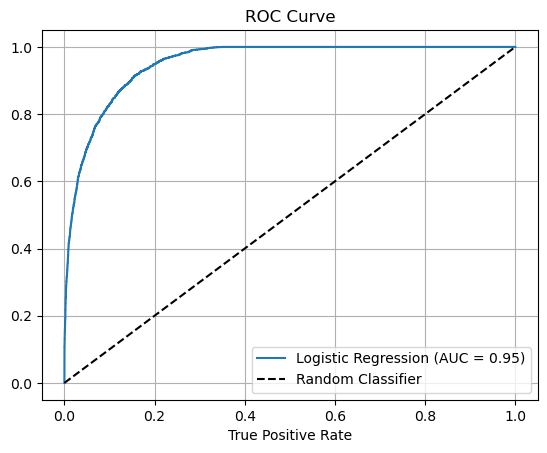

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,roc_curve

y_prob_lr = classifier_lr.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr_lr, tpr_lr, label = f'Logistic Regression (AUC = {auc_lr:,.2f})')
plt.plot([0,1], [0,1], 'k--', label = 'Random Classifier')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc= 'lower right')
plt.grid()
plt.show()

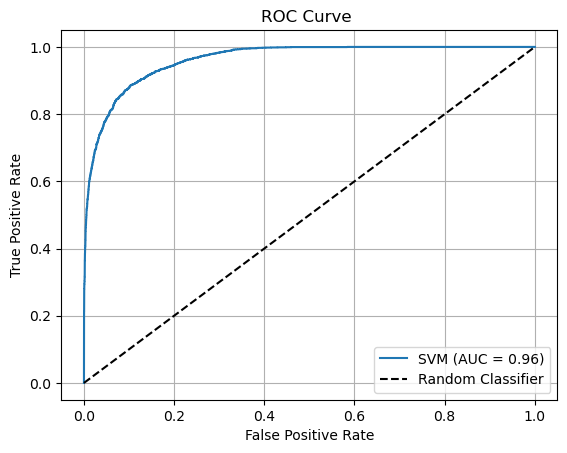

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score

y_score_svm = classifier_svm.decision_function(X_test)


fpr_svm, tpr_svm, thresholds = roc_curve(y_test, y_score_svm)


auc_svm = roc_auc_score(y_test, y_score_svm)

plt.plot(fpr_svm, tpr_svm, label = f'SVM (AUC = {auc_svm:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve ')

plt.legend(loc='lower right')
plt.grid()
plt.show()

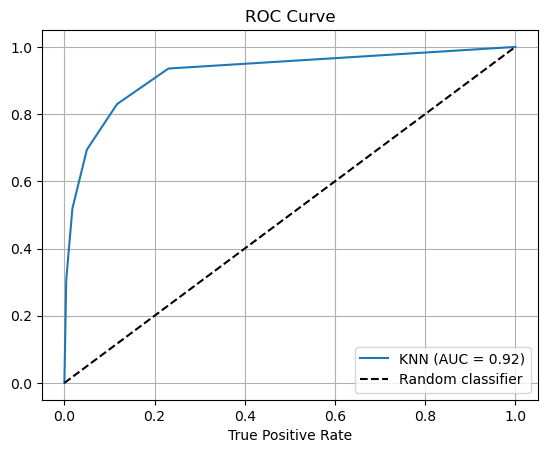

In [35]:
y_prob_knn = classifier_knn.predict_proba(X_test)[:, 1]

fpr_knn, tpr_knn, _ = roc_curve(y_test,y_prob_knn)

auc_knn = roc_auc_score(y_test, y_prob_knn)


plt.plot(fpr_knn, tpr_knn, label = f'KNN (AUC = {auc_knn:,.2f})')
plt.plot([0,1], [0,1], 'k--', label = 'Random classifier')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc= 'lower right')
plt.grid()
plt.show()

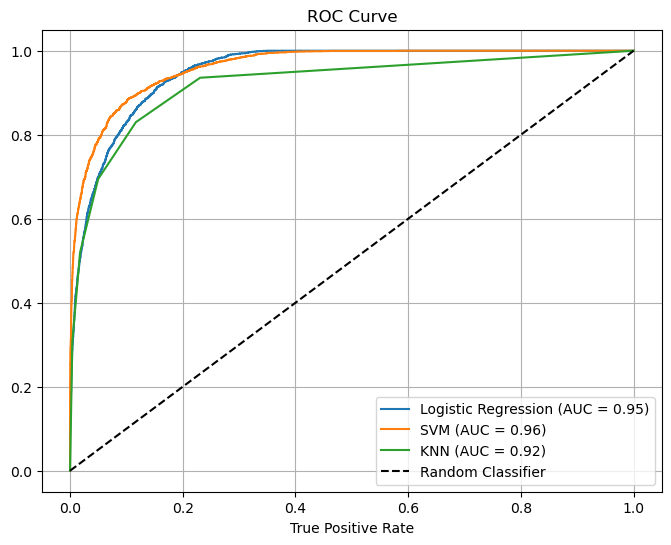

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))

plt.plot(fpr_lr, tpr_lr, label = f'Logistic Regression (AUC = {auc_lr:,.2f})')
plt.plot(fpr_svm, tpr_svm, label = f'SVM (AUC = {auc_svm:,.2f})')
plt.plot(fpr_knn, tpr_knn, label = f'KNN (AUC = {auc_knn:,.2f})')
plt.plot([0,1], [0,1], 'k--', label = 'Random Classifier')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc = 'lower right')
plt.grid()
plt.show()

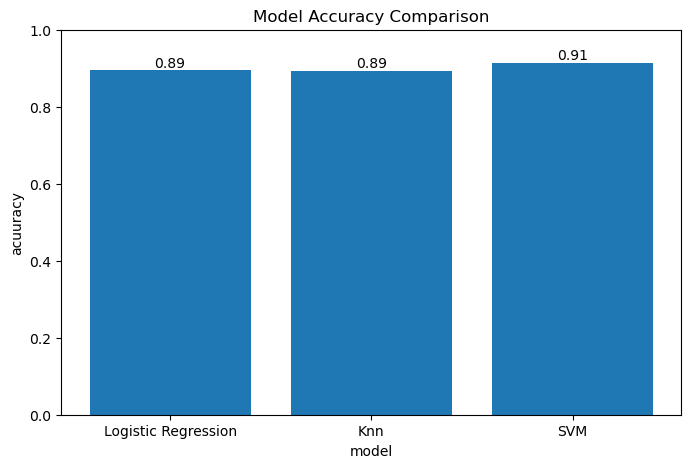

In [43]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

y_pred = classifier_lr.predict(X_test)
y_pred = classifier_knn.predict(X_test)
y_pred = classifier_svm.predict(X_test)

auc_score_lr = accuracy_score(y_test, y_pred_lr)
auc_score_knn = accuracy_score(y_test, y_pred_knn)
auc_score_svc = accuracy_score(y_test, y_pred_svc)

model = ['Logistic Regression', 'Knn', 'SVM']
acuuracy = [auc_score_lr, auc_score_knn, auc_score_svc]

plt.figure(figsize=(8,5))
plt.ylim(0, 1)
bars = plt.bar(model, acuuracy)
plt.ylabel('acuuracy')
plt.xlabel('model')
plt.title('Model Accuracy Comparison')


for bar, accuracy in zip(bars, acuuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{accuracy:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()